# Medical Image Diagnosis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/devicavasan/ML-Portfolio/blob/main/clustering/medical-image-diagnosis/notebook.ipynb)

A clustering project that groups chest X-ray images to identify patterns and detect pneumonia using unsupervised learning.

**Dataset:** Chest X-Ray Images (Pneumonia) - Kaggle
**Models Used:** K-Means, Agglomerative Clustering
**Approach:** Feature extraction from X-ray images then clustering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2

from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip

print("Dataset downloaded successfully")

Saving kaggle (2).json to kaggle (2).json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:17<00:00, 144MB/s]

Dataset downloaded successfully


In [3]:
# Load images from normal and pneumonia folders
def load_images(folder, label, max_images=200):
    images, labels = [], []
    for fname in os.listdir(folder)[:max_images]:
        path = os.path.join(folder, fname)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, (64, 64))
            images.append(img.flatten())
            labels.append(label)
    return images, labels

normal_imgs, normal_labels = load_images(
    'chest_xray/train/NORMAL', 0
)
pneumonia_imgs, pneumonia_labels = load_images(
    'chest_xray/train/PNEUMONIA', 1
)

X_raw = np.array(normal_imgs + pneumonia_imgs)
y_true = np.array(normal_labels + pneumonia_labels)

print(f"Total images loaded: {X_raw.shape[0]}")
print(f"Normal: {np.sum(y_true==0)} | Pneumonia: {np.sum(y_true==1)}")

Total images loaded: 400
Normal: 200 | Pneumonia: 200


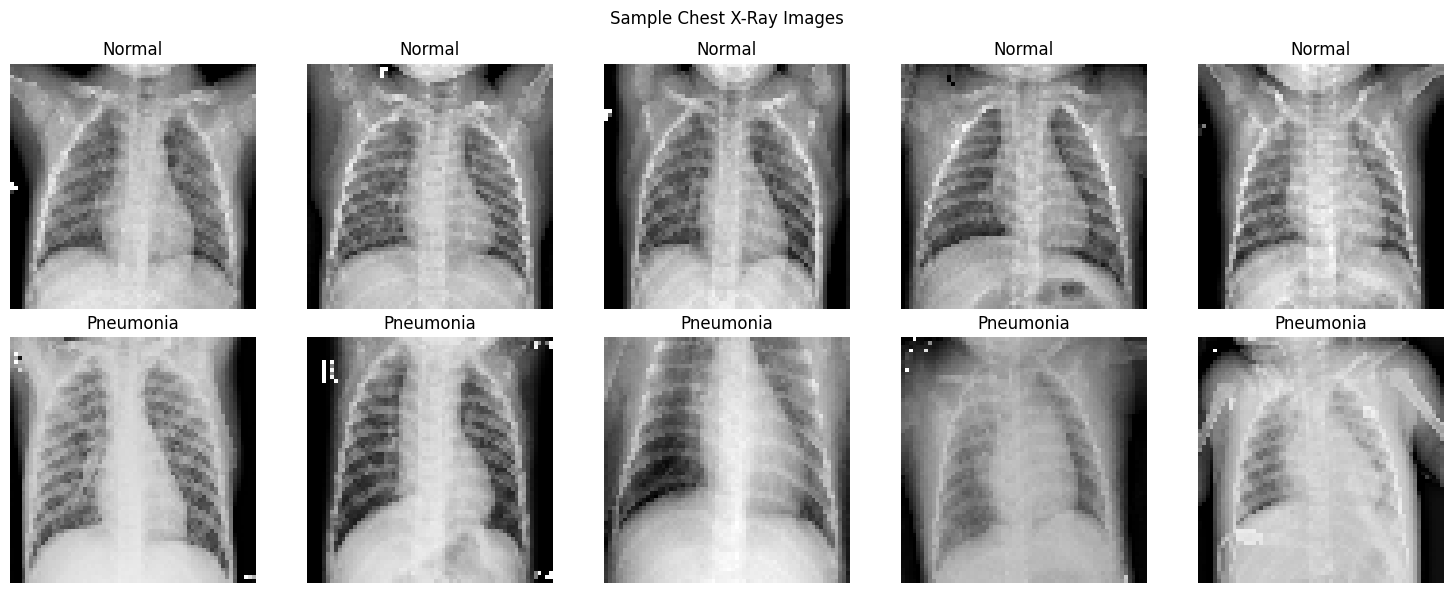

In [4]:
# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

normal_idx = np.where(y_true == 0)[0][:5]
pneumonia_idx = np.where(y_true == 1)[0][:5]

for i, ax in enumerate(axes[0]):
    ax.imshow(X_raw[normal_idx[i]].reshape(64, 64), cmap='gray')
    ax.set_title("Normal")
    ax.axis('off')

for i, ax in enumerate(axes[1]):
    ax.imshow(X_raw[pneumonia_idx[i]].reshape(64, 64), cmap='gray')
    ax.set_title("Pneumonia")
    ax.axis('off')

plt.suptitle("Sample Chest X-Ray Images")
plt.tight_layout()
plt.show()

Explained variance with 50 components: 82.90%


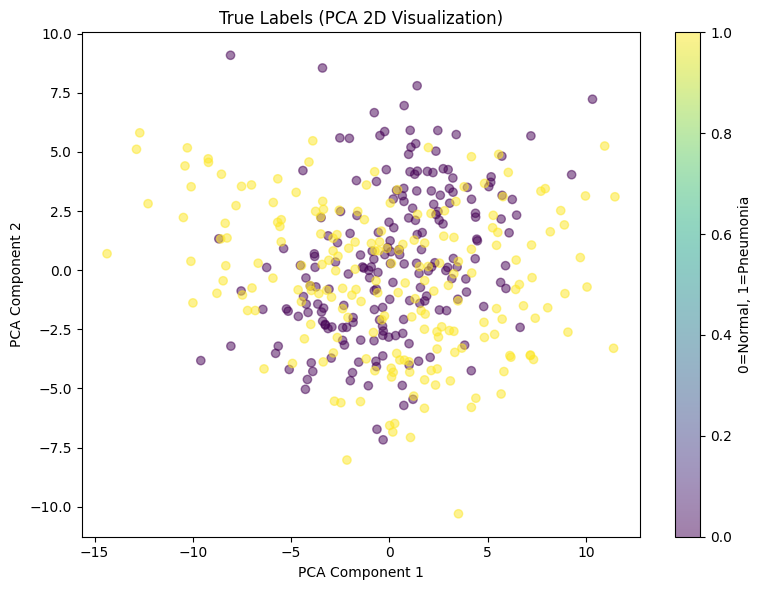

In [5]:
# Normalize and reduce dimensions with PCA
X_scaled = X_raw / 255.0

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance with 50 components: {pca.explained_variance_ratio_.sum():.2%}")

# Reduce to 2D for visualization
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=y_true, cmap='viridis', alpha=0.5)
plt.colorbar(scatter, label='0=Normal, 1=Pneumonia')
plt.title("True Labels (PCA 2D Visualization)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.tight_layout()
plt.show()

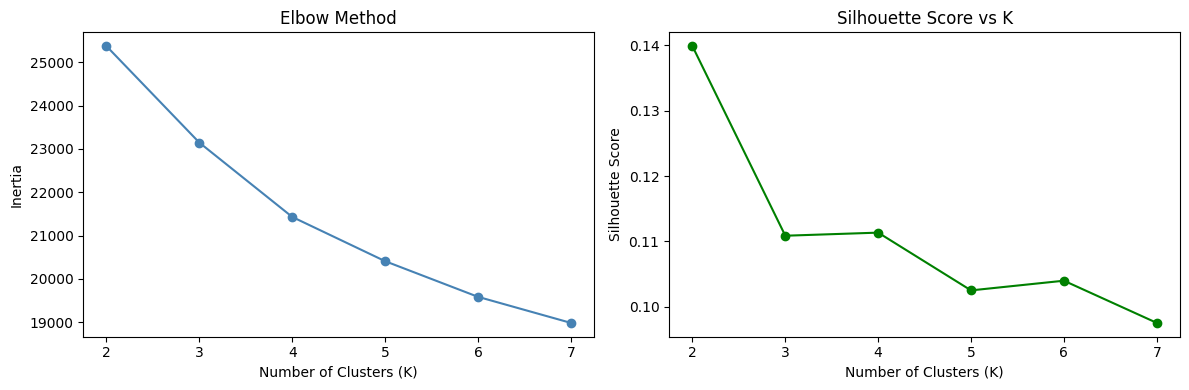

In [6]:
# Elbow method to find optimal K
inertias = []
sil_scores = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertias, marker='o', color='steelblue')
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_range, sil_scores, marker='o', color='green')
axes[1].set_title("Silhouette Score vs K")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

K-Means Silhouette Score: 0.1398
K-Means Adjusted Rand Index: 0.0005


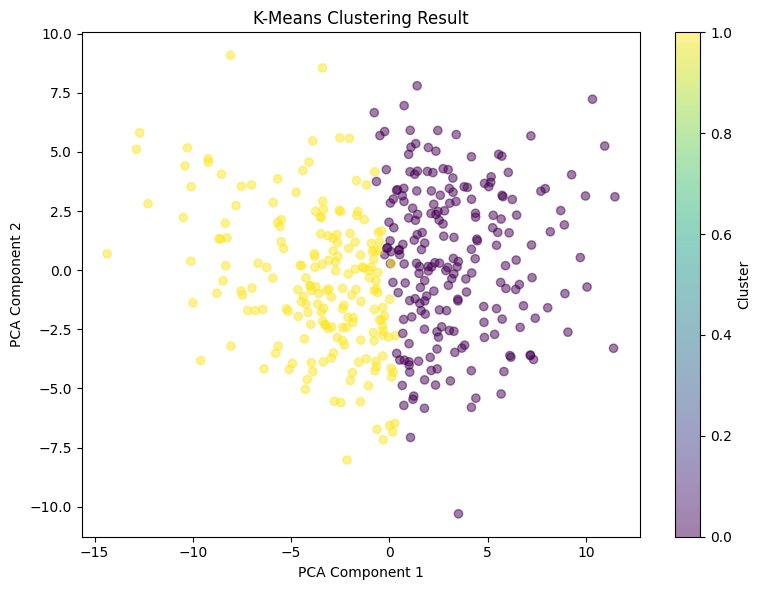

In [7]:
# K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_pca)

sil = silhouette_score(X_pca, kmeans_labels)
ari = adjusted_rand_score(y_true, kmeans_labels)

print(f"K-Means Silhouette Score: {sil:.4f}")
print(f"K-Means Adjusted Rand Index: {ari:.4f}")

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=kmeans_labels, cmap='viridis', alpha=0.5)
plt.colorbar(scatter, label='Cluster')
plt.title("K-Means Clustering Result")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.tight_layout()
plt.show()

Agglomerative Silhouette Score: 0.1161
Agglomerative Adjusted Rand Index: 0.0359


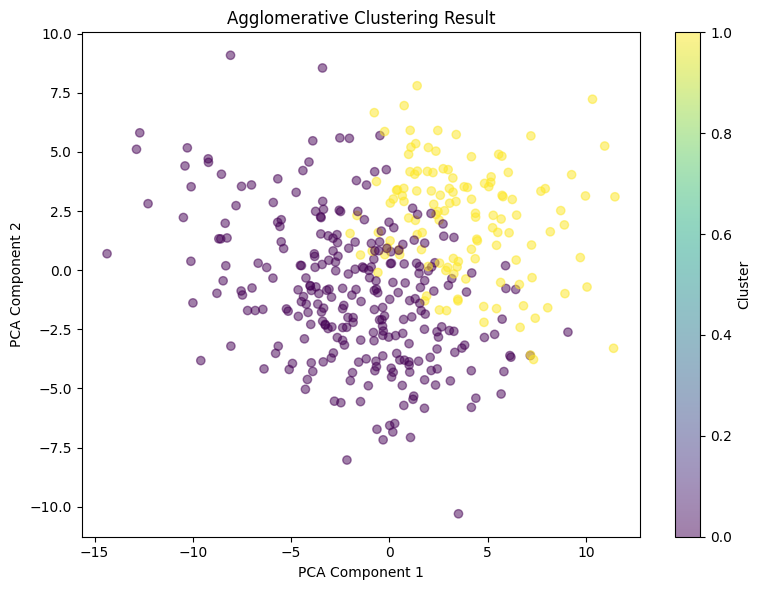

In [8]:
# Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=2)
agg_labels = agg.fit_predict(X_pca)

sil = silhouette_score(X_pca, agg_labels)
ari = adjusted_rand_score(y_true, agg_labels)

print(f"Agglomerative Silhouette Score: {sil:.4f}")
print(f"Agglomerative Adjusted Rand Index: {ari:.4f}")

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=agg_labels, cmap='viridis', alpha=0.5)
plt.colorbar(scatter, label='Cluster')
plt.title("Agglomerative Clustering Result")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.tight_layout()
plt.show()

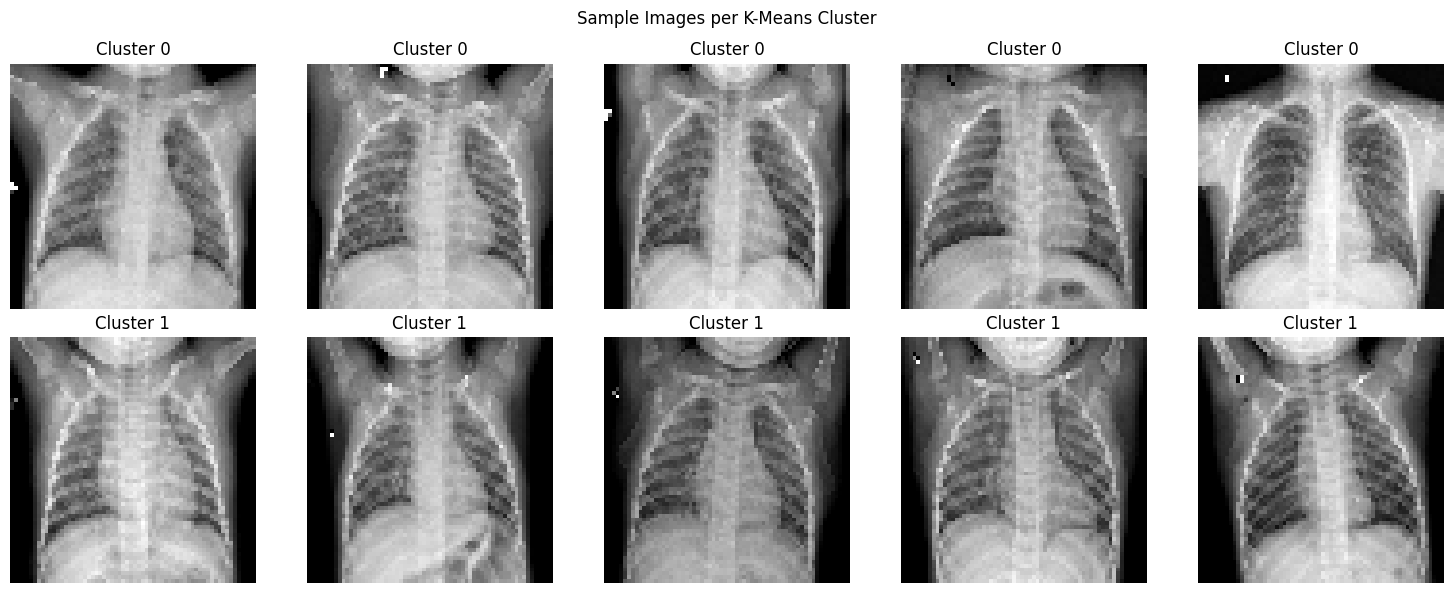

In [9]:
# Visualize cluster samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for cluster in [0, 1]:
    cluster_idx = np.where(kmeans_labels == cluster)[0][:5]
    for i, ax in enumerate(axes[cluster]):
        ax.imshow(X_raw[cluster_idx[i]].reshape(64, 64), cmap='gray')
        ax.set_title(f"Cluster {cluster}")
        ax.axis('off')

plt.suptitle("Sample Images per K-Means Cluster")
plt.tight_layout()
plt.show()

               Silhouette Score  Adjusted Rand Index
K-Means                  0.1398               0.0005
Agglomerative            0.1161               0.0359


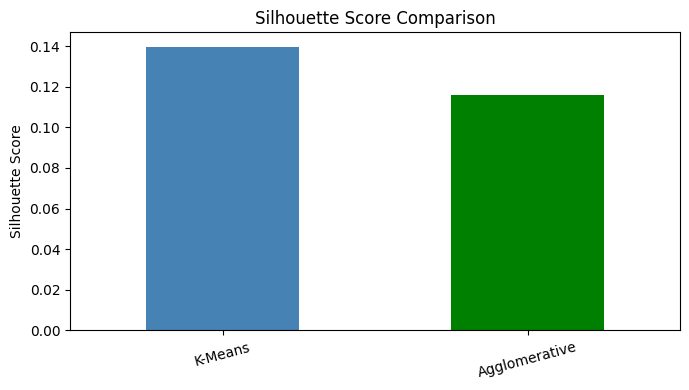

In [10]:
# Results comparison
results = {
    "K-Means": {
        "Silhouette Score": round(silhouette_score(X_pca, kmeans_labels), 4),
        "Adjusted Rand Index": round(adjusted_rand_score(y_true, kmeans_labels), 4)
    },
    "Agglomerative": {
        "Silhouette Score": round(silhouette_score(X_pca, agg_labels), 4),
        "Adjusted Rand Index": round(adjusted_rand_score(y_true, agg_labels), 4)
    }
}

results_df = pd.DataFrame(results).T
print(results_df)

results_df['Silhouette Score'].plot(
    kind='bar',
    color=['steelblue', 'green'],
    figsize=(7, 4),
    title='Silhouette Score Comparison'
)
plt.ylabel("Silhouette Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Results Summary

| Model | Silhouette Score | Adjusted Rand Index |
|-------|-----------------|---------------------|
| K-Means | 0.1398 | 0.0005 |
| Agglomerative | 0.1161 | 0.0359 |

**K-Means achieved a slightly better Silhouette Score on chest X-ray clustering.**

### Key Takeaways
- PCA reduces 4096 pixel features (64x64) to 50 components efficiently
- Low Adjusted Rand Index shows clustering without labels is challenging on real X-rays
- Clustering groups X-rays by visual similarity without any labeled data
- Real medical diagnosis requires supervised learning for higher accuracy